# End-to-End LSTM Crypto Predictor & Backtester

Цей комплексний блокнот поєднує в собі повний цикл машинного навчання для алгоритмічного трейдингу:
1. **Завантаження та підготовка даних** (Feature Engineering).
2. **Масове навчання нейронних мереж LSTM** для 10 різних криптовалют.
3. **Глибокий аналіз якості моделей** (метрики MAE, RMSE, MAPE на Test Set).
4. **Симуляція торгівлі (Backtesting)** за допомогою створених моделей з детальними графіками точок входу (Buy/Sell) та динаміки балансу портфеля.

In [1]:
import numpy as np
import pandas as pd
import warnings
import yfinance as yf
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output, display

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, LSTM, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (14, 7)

## ЧАСТИНА 1: Клас CryptoPredictor
Побудовано архітектуру нейромережі, цикл навчання та інструменти оцінки точності.

In [2]:
class CryptoPredictor:
    def __init__(self, ticker='BTC-USD', start_date='2019-01-01', window_size=60, test_ratio=0.15):
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
        self.window_size = window_size
        self.test_ratio = test_ratio
        self.scaler = MinMaxScaler(feature_range=(0, 1))
        self.model = None
        self.df_features = None
        self.history = None

    def download_data(self):
        df = yf.download(self.ticker, start=self.start_date, end=self.end_date, auto_adjust=True, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df.dropna(inplace=True)
        self.df_raw = df
        return df

    def _calc_rsi(self, series, period=14):
        delta = series.diff()
        gain = delta.clip(lower=0)
        loss = -delta.clip(upper=0)
        avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
        avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
        rs = avg_gain / (avg_loss + 1e-10)
        return 100 - (100 / (1 + rs))

    def _calc_macd(self, series):
        ema_fast = series.ewm(span=12, adjust=False).mean()
        ema_slow = series.ewm(span=26, adjust=False).mean()
        macd_line = ema_fast - ema_slow
        signal_line = macd_line.ewm(span=9, adjust=False).mean()
        return macd_line, signal_line

    def engineer_features(self):
        if hasattr(self, 'df_raw') is False: self.download_data()
        df = self.df_raw.copy()
        close = df['Close']
        df['SMA_20'] = close.rolling(window=20).mean()
        df['SMA_50'] = close.rolling(window=50).mean()
        df['RSI_14'] = self._calc_rsi(close)
        df['MACD'], df['MACD_Signal'] = self._calc_macd(close)
        df['Daily_Return'] = close.pct_change()
        df['Volatility_10'] = df['Daily_Return'].rolling(window=10).std()

        feature_cols = ['Close', 'High', 'Low', 'Volume', 'SMA_20', 'SMA_50', 'RSI_14', 'MACD', 'MACD_Signal',
                        'Daily_Return', 'Volatility_10']
        df = df[feature_cols].dropna()
        self.close_col_idx = feature_cols.index('Close')
        self.df_features = df
        return df

    def prepare_data(self):
        dataset = self.df_features.values
        n_test = int(len(dataset) * self.test_ratio)
        n_train = len(dataset) - n_test
        self.scaler.fit(dataset[:n_train])
        scaled_data = self.scaler.transform(dataset)

        X, y = [], []
        for i in range(self.window_size, len(scaled_data)):
            X.append(scaled_data[i - self.window_size:i])
            y.append(scaled_data[i, self.close_col_idx])

        X, y = np.array(X), np.array(y)
        split = n_train - self.window_size
        return X[:split], y[:split], X[split:], y[split:]

    def build_model(self, n_features):
        model = Sequential([
            Bidirectional(LSTM(128, return_sequences=True), input_shape=(self.window_size, n_features)),
            Dropout(0.3),
            BatchNormalization(),
            Bidirectional(LSTM(64)),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer=Adam(1e-3), loss='huber')
        self.model = model

    def train(self, X_train, y_train):
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
        ]
        self.history = self.model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, callbacks=callbacks, verbose=0)
        return self.history

    def evaluate_model(self, X_test, y_test):
        """Оцінює модель на тестовій вибірці (Test Set)."""
        pred_scaled = self.model.predict(X_test, verbose=0)
        n_features = X_test.shape[2]
        
        dummy_pred = np.zeros((len(pred_scaled), n_features))
        dummy_pred[:, self.close_col_idx] = pred_scaled.flatten()
        preds = self.scaler.inverse_transform(dummy_pred)[:, self.close_col_idx]
        
        dummy_true = np.zeros((len(y_test), n_features))
        dummy_true[:, self.close_col_idx] = y_test.flatten()
        trues = self.scaler.inverse_transform(dummy_true)[:, self.close_col_idx]
        
        mae = mean_absolute_error(trues, preds)
        mse = mean_squared_error(trues, preds)
        mape = np.mean(np.abs((trues - preds) / trues)) * 100
        
        return trues, preds, mae, mse, mape

    def save(self):
        os.makedirs('models', exist_ok=True)
        name = self.ticker.replace('-', '_').lower()
        self.model.save(f'models/{name}_model.keras')
        joblib.dump(self.scaler, f'models/{name}_scaler.gz')

---
## ЧАСТИНА 2: Навчання та Аналіз Метрик
Навчаємо 10 моделей для різних монет.

In [4]:
tickers = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'SOL-USD', 'XRP-USD',
    'ADA-USD', 'DOGE-USD', 'DOT-USD', 'MATIC-USD', 'LTC-USD'
]
SKIP_TRAINING = False

results = []
training_histories = {}
btc_predictions = None

if not SKIP_TRAINING:
    for idx, ticker in enumerate(tickers, 1):
        print(f"[{idx}/{len(tickers)}] Навчання для {ticker}...")
        
        predictor = CryptoPredictor(ticker=ticker)
        predictor.engineer_features()
        xt, yt, xv, yv = predictor.prepare_data()
        
        predictor.build_model(xt.shape[2])
        history = predictor.train(xt, yt)
        training_histories[ticker] = history.history
        
        trues, preds, mae, mse, mape = predictor.evaluate_model(xv, yv)
        
        results.append({
            'Криптовалюта': ticker,
            'MAE ($)': mae,
            'RMSE ($)': np.sqrt(mse),
            'MAPE (%)': mape
        })
        
        if ticker == 'BTC-USD' or btc_predictions is None:
            dates = predictor.df_features.index[-len(trues):]
            btc_predictions = (ticker, trues, preds, dates)
            
        predictor.save()
        print(f"Збережено! MAPE: {mape:.2f}% | RMSE: ${np.sqrt(mse):.2f}\n")

    print("Усі моделі успішно навчені та протестовані!")
else:
    print("Навчання пропущено.")

[1/10] Навчання для BTC-USD...
Збережено! MAPE: 10.49% | RMSE: $12292.51

[2/10] Навчання для ETH-USD...
Збережено! MAPE: 4.20% | RMSE: $164.10

[3/10] Навчання для BNB-USD...
Збережено! MAPE: 10.72% | RMSE: $145.23

[4/10] Навчання для SOL-USD...
Збережено! MAPE: 6.17% | RMSE: $10.52

[5/10] Навчання для XRP-USD...
Збережено! MAPE: 36.47% | RMSE: $0.99

[6/10] Навчання для ADA-USD...
Збережено! MAPE: 6.72% | RMSE: $0.04

[7/10] Навчання для DOGE-USD...
Збережено! MAPE: 8.87% | RMSE: $0.02

[8/10] Навчання для DOT-USD...
Збережено! MAPE: 84.07% | RMSE: $1.61

[9/10] Навчання для MATIC-USD...
Збережено! MAPE: 11.45% | RMSE: $0.06

[10/10] Навчання для LTC-USD...
Збережено! MAPE: 3.69% | RMSE: $4.43

Усі моделі успішно навчені та протестовані!


,MAE ($),RMSE ($),MAPE (%)
Криптовалюта,,,
BTC-USD,10507.49,12292.51,10.49%
ETH-USD,125.40,164.10,4.20%
BNB-USD,99.10,145.23,10.72%
SOL-USD,8.30,10.52,6.17%
XRP-USD,0.86,0.99,36.47%
ADA-USD,0.03,0.04,6.72%
DOGE-USD,0.01,0.02,8.87%
DOT-USD,1.36,1.61,84.07%
MATIC-USD,0.05,0.06,11.45%


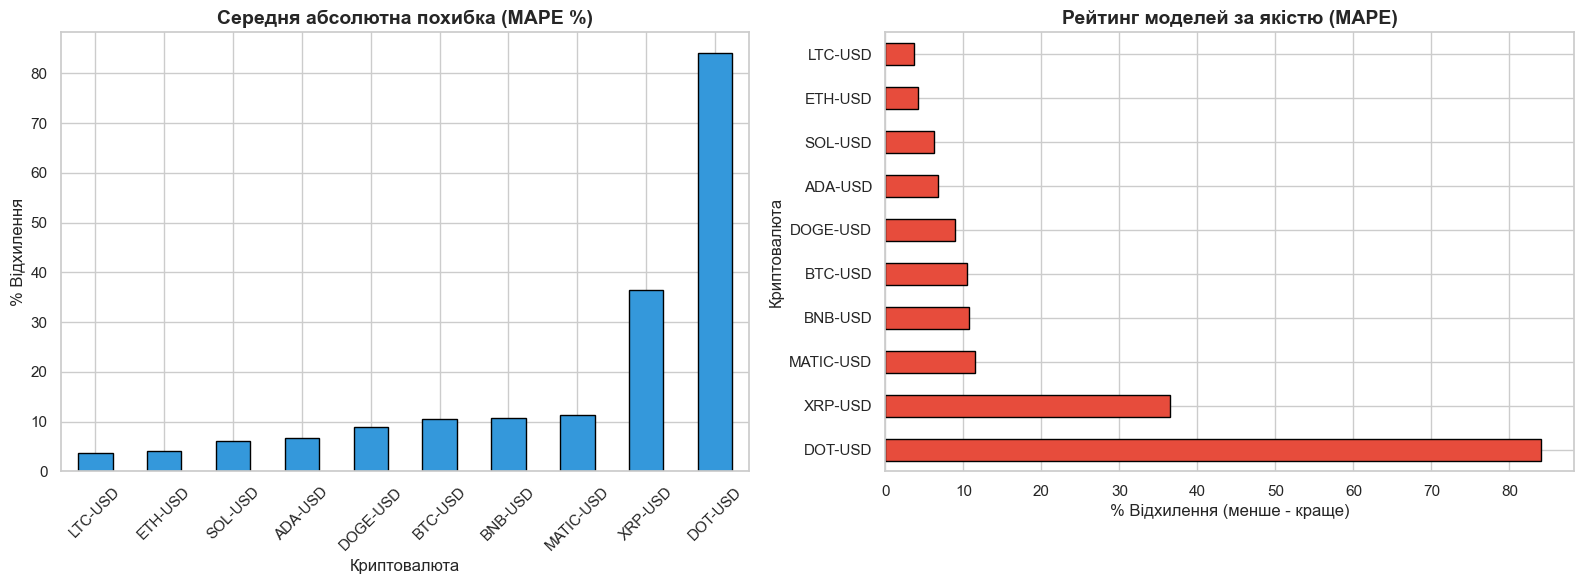

In [8]:
if not SKIP_TRAINING:
    #Таблиця градієнтів
    metrics_df = pd.DataFrame(results).set_index('Криптовалюта')
    display(
    metrics_df.style
    .background_gradient(cmap='RdYlGn_r', subset=['MAPE (%)', 'RMSE ($)'])
    .format({'MAE ($)': '{:.2f}', 'RMSE ($)': '{:.2f}', 'MAPE (%)': '{:.2f}%'})
    )


    #Побудова графіків
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    metrics_df['MAPE (%)'].sort_values().plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
    axes[0].set_title('Середня абсолютна похибка (MAPE %)', fontweight='bold', fontsize=14)
    axes[0].set_ylabel('% Відхилення')
    axes[0].tick_params(axis='x', rotation=45)

    metrics_df['MAPE (%)'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black')
    axes[1].set_title('Рейтинг моделей за якістю (MAPE)', fontweight='bold', fontsize=14)
    axes[1].set_xlabel('% Відхилення (менше - краще)')

    plt.tight_layout()
    plt.show()

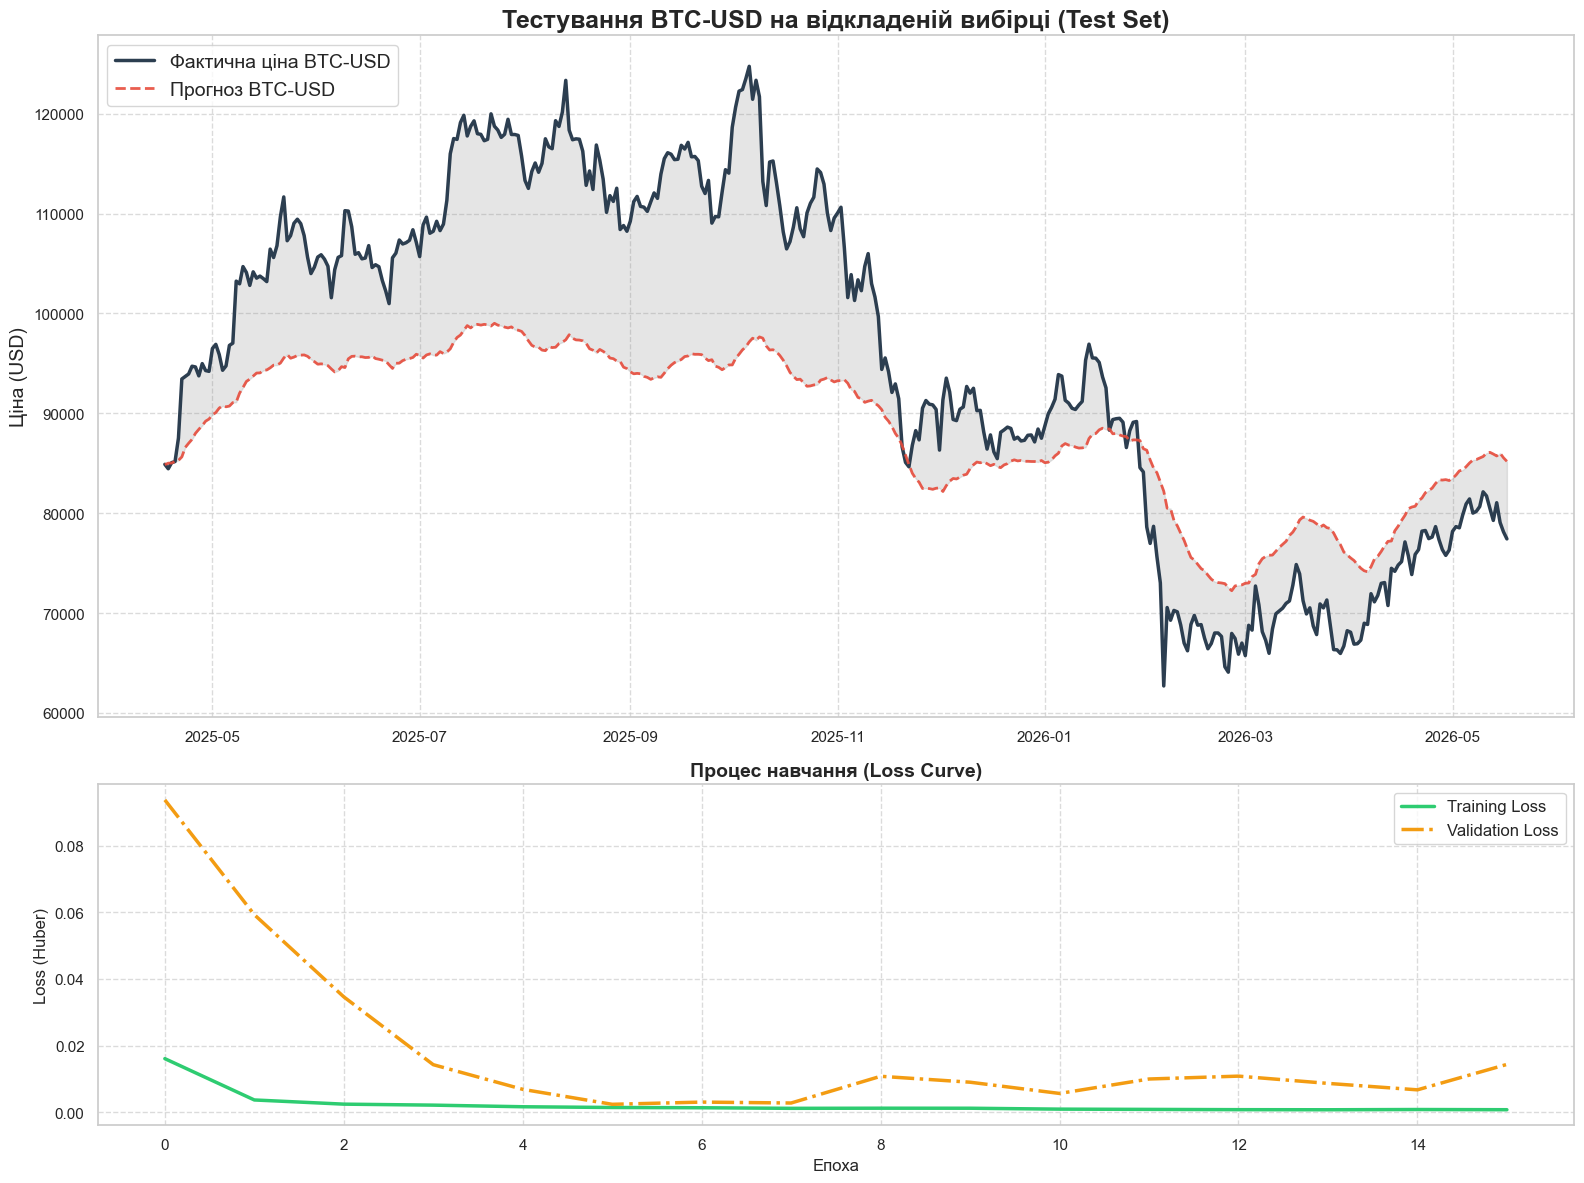

In [9]:
if not SKIP_TRAINING and btc_predictions is not None:
    ticker, trues, preds, dates = btc_predictions

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [2, 1]})
    
    ax1.plot(dates, trues, label=f'Фактична ціна {ticker}', color='#2c3e50', linewidth=2.5)
    ax1.plot(dates, preds, label=f'Прогноз {ticker}', color='#e74c3c', linestyle='--', linewidth=2, alpha=0.9)
    ax1.set_title(f'Тестування {ticker} на відкладеній вибірці (Test Set)', fontsize=18, fontweight='bold')
    ax1.set_ylabel('Ціна (USD)', fontsize=14)
    ax1.legend(fontsize=14, loc='upper left')
    ax1.fill_between(dates, trues, preds, color='gray', alpha=0.2, label='Похибка')
    ax1.grid(True, linestyle='--', alpha=0.7)

    if ticker in training_histories:
        hist = training_histories[ticker]
        ax2.plot(hist['loss'], label='Training Loss', color='#2ecc71', linewidth=2.5)
        ax2.plot(hist['val_loss'], label='Validation Loss', color='#f39c12', linewidth=2.5, linestyle='-.')
        ax2.set_title(f'Процес навчання (Loss Curve)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Епоха', fontsize=12)
        ax2.set_ylabel('Loss (Huber)', fontsize=12)
        ax2.legend(fontsize=12)
        ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

---
## ЧАСТИНА 3: Симуляція торгівлі (Backtesting)
Цей блок використовує навчені моделі, щоб симулювати реальну торгівлю з початковим депозитом (наприклад, 1000 USDT). Модель приймає рішення: `BUY` (якщо очікується ріст > 0.5%), `SELL` (якщо очікується падіння), або `Hold`.

In [31]:
def run_final_backtest(ticker_to_trade='DOGE-USD', usdt_initial=1000.0, period='3mo', interval='1h'):
    name = ticker_to_trade.replace('-', '_').lower()
    MODEL_PATH = f'models/{name}_model.keras'
    SCALER_PATH = f'models/{name}_scaler.gz'
    
    if not os.path.exists(MODEL_PATH) or not os.path.exists(SCALER_PATH):
        print(f"Помилка: Не знайдено збереженої моделі для {ticker_to_trade}.")
        return None

    print(f"Завантаження моделі та даних для {ticker_to_trade}...")
    model = load_model(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)

    raw_data = yf.download(ticker_to_trade, period=period, interval=interval, auto_adjust=True, progress=False)
    if isinstance(raw_data.columns, pd.MultiIndex):
        raw_data.columns = raw_data.columns.get_level_values(0)

    # Feature Engineering для нових даних
    predictor = CryptoPredictor(ticker=ticker_to_trade)
    predictor.df_raw = raw_data
    df = predictor.engineer_features()
    feature_cols = df.columns.tolist()
    n_features = len(feature_cols)
    close_idx = feature_cols.index('Close')

    dataset = df.values
    scaled_dataset = scaler.transform(dataset)

    usdt = usdt_initial
    asset_amount = 0.0
    window_size = 60
    results_bt = []

    print("Проведення бектесту...")
    for i in range(window_size, len(scaled_dataset)):
        current_time = df.index[i]
        current_price = df['Close'].iloc[i]

        X_window = scaled_dataset[i - window_size:i]
        X_window = np.reshape(X_window, (1, window_size, n_features))
        pred_scaled = model.predict(X_window, verbose=0)

        dummy = np.zeros((1, n_features))
        dummy[0, close_idx] = pred_scaled[0][0]
        predicted_price = scaler.inverse_transform(dummy)[0, close_idx]

        action = "Hold"
        if predicted_price > current_price * 1.005 and usdt > 10:
            asset_amount = usdt / current_price
            usdt = 0
            action = "BUY"
        elif predicted_price < current_price and asset_amount > 0:
            usdt = asset_amount * current_price
            asset_amount = 0
            action = "SELL"

        total_val = usdt + (asset_amount * current_price)
        results_bt.append({
            'Time': current_time,
            'Price': current_price,
            'Predicted': predicted_price,
            'Action': action,
            'Balance': total_val,
            'Crypto_Amount': asset_amount
        })

    res_df = pd.DataFrame(results_bt).set_index('Time')
    final_total = usdt + (asset_amount * df['Close'].iloc[-1])
    profit = ((final_total - usdt_initial) / usdt_initial) * 100
    
    print(f"\n{'='*50}")
    print(f" {ticker_to_trade} Результат: {profit:.2f}% | Фінальний баланс: {final_total:.2f} USDT")
    print(f"{'='*50}\n")
    
    return res_df, ticker_to_trade

### Запуск бектесту та візуалізація результатів

Завантаження моделі та даних для BTC-USD...
Проведення бектесту...

 BTC-USD Результат: 17.39% | Фінальний баланс: 1173.89 USDT



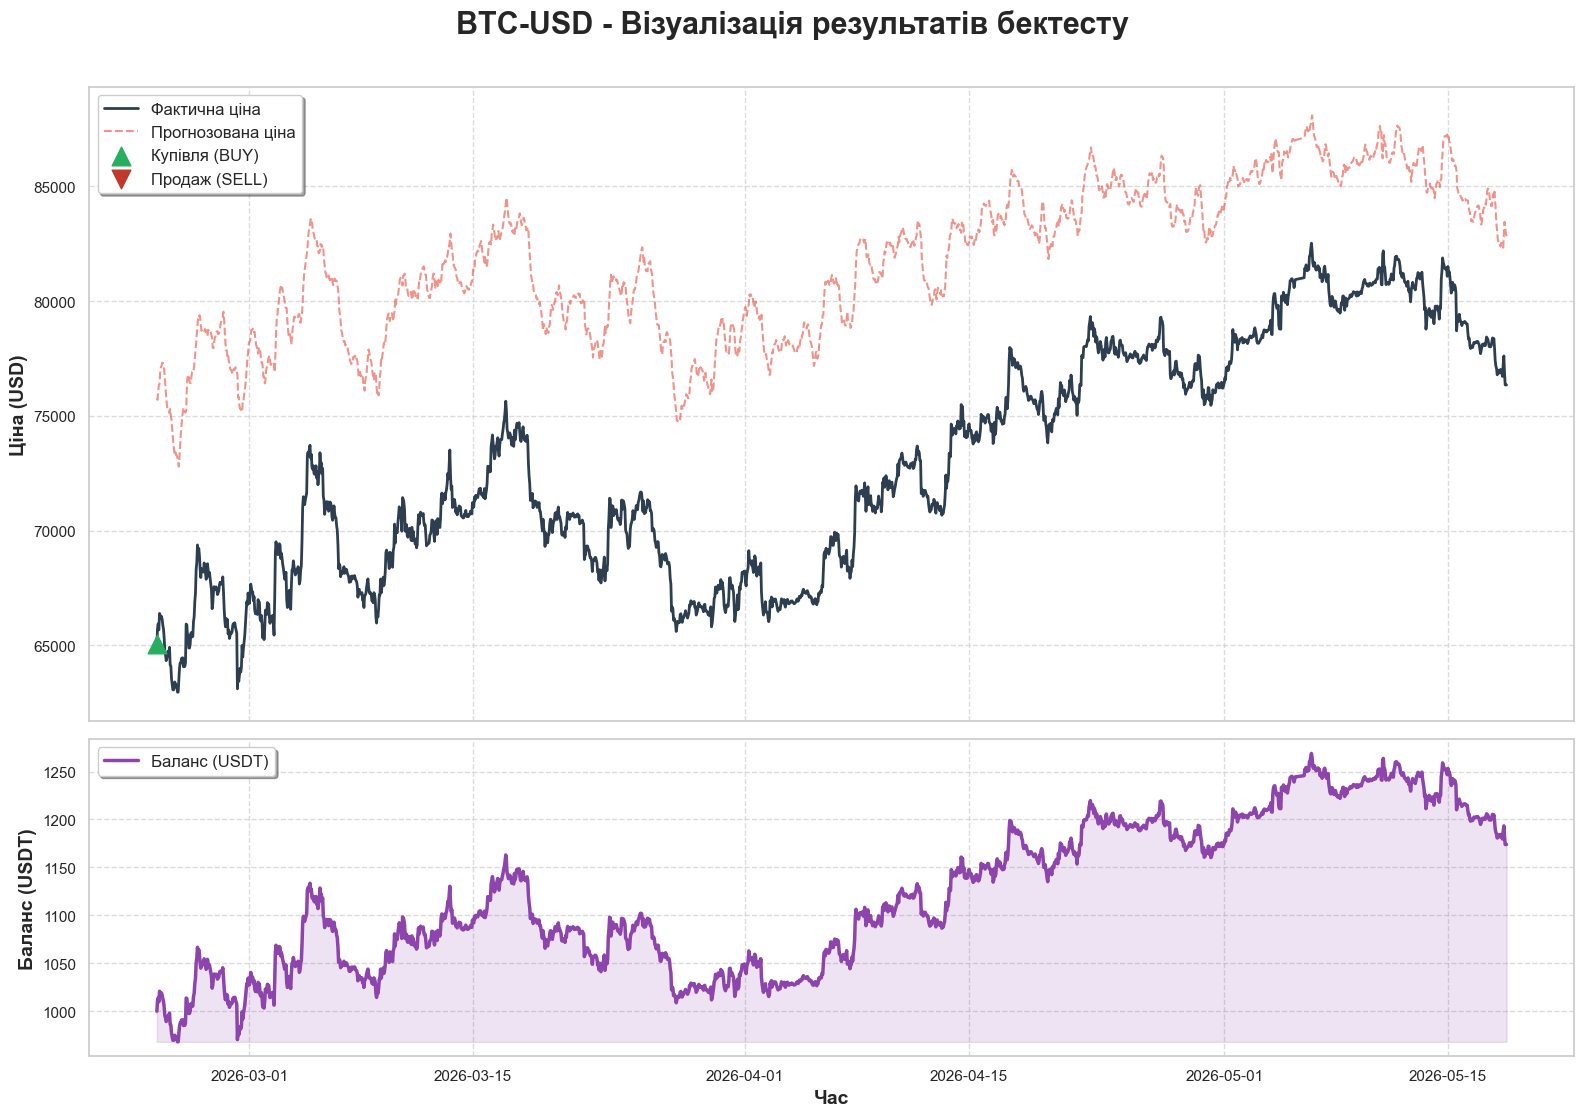


Деталізований результат (останні 10 кроків):


,Price,Predicted,Action,Balance,Crypto_Amount
Time,,,,,
2026-05-18 07:00:00+00:00,77021.468750,82377.708606,Hold,1184.283215,0.015376
2026-05-18 08:00:00+00:00,76972.093750,82532.940549,Hold,1183.524024,0.015376
2026-05-18 09:00:00+00:00,76884.851562,82520.515647,Hold,1182.182587,0.015376
2026-05-18 10:00:00+00:00,76717.257812,82476.259561,Hold,1179.605663,0.015376
2026-05-18 11:00:00+00:00,77238.507812,82327.539097,Hold,1187.620410,0.015376
2026-05-18 12:00:00+00:00,77607.781250,82901.952818,Hold,1193.298364,0.015376
2026-05-18 13:00:00+00:00,76883.460938,83448.233534,Hold,1182.161205,0.015376
2026-05-18 14:00:00+00:00,76343.890625,83216.596987,Hold,1173.864764,0.015376
2026-05-18 15:00:00+00:00,76343.007812,82943.456629,Hold,1173.851189,0.015376


In [32]:
TRADE_TICKER = 'BTC-USD'

out = run_final_backtest(ticker_to_trade=TRADE_TICKER, period='3mo', interval='1h')

if out is not None:
    results_df, ticker = out

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)
    fig.suptitle(f'{ticker} - Візуалізація результатів бектесту', fontsize=22, fontweight='bold', y=0.96)

    # Графік 1: Ціна та прогнози
    ax1.plot(results_df.index, results_df['Price'], label='Фактична ціна', color='#2c3e50', linewidth=2)
    ax1.plot(results_df.index, results_df['Predicted'], label='Прогнозована ціна', color='#e74c3c', alpha=0.6, linestyle='--', linewidth=1.5)

    buy_signals = results_df[results_df['Action'] == 'BUY']
    sell_signals = results_df[results_df['Action'] == 'SELL']

    ax1.scatter(buy_signals.index, buy_signals['Price'], marker='^', color='#27ae60', s=180, label='Купівля (BUY)', zorder=5)
    ax1.scatter(sell_signals.index, sell_signals['Price'], marker='v', color='#c0392b', s=180, label='Продаж (SELL)', zorder=5)

    ax1.set_ylabel('Ціна (USD)', fontsize=14, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
    ax1.grid(True, linestyle='--', alpha=0.7)

    # Графік 2: Баланс портфеля
    ax2.plot(results_df.index, results_df['Balance'], label='Баланс (USDT)', color='#8e44ad', linewidth=2.5)
    ax2.fill_between(results_df.index, results_df['Balance'], results_df['Balance'].min(), color='#8e44ad', alpha=0.15)
    ax2.set_ylabel('Баланс (USDT)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Час', fontsize=14, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\nДеталізований результат (останні 10 кроків):")
    def color_action(val):
        color = '#27ae60' if val == 'BUY' else '#c0392b' if val == 'SELL' else 'black'
        return f'color: {color}; font-weight: bold'

    try:
        styled_df = results_df.tail(10).style.applymap(color_action, subset=['Action']).format({
            'Price': '{:.4f}',
            'Predicted': '{:.4f}',
            'Balance': '{:.2f}',
            'Crypto_Amount': '{:.6f}'
        })
        display(styled_df)
    except Exception as e:
        display(results_df.tail(10))